<a href="https://colab.research.google.com/github/EnzoSalvini/Calculo_numerico/blob/main/Atv1CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Item A da lista
Variável  n         Método  Aproximação       Ea       Er         E%
      x1  0 Arredondamento     3.000000 0.141593 0.045070   4.507034
      x1  0    Truncamento     3.000000 0.141593 0.045070   4.507034
      x1  1 Arredondamento     3.100000 0.041593 0.013239   1.323935
      x1  1    Truncamento     3.100000 0.041593 0.013239   1.323935
      x1  2 Arredondamento     3.140000 0.001593 0.000507   0.050696
      x1  2    Truncamento     3.140000 0.001593 0.000507   0.050696
      x1  3 Arredondamento     3.142000 0.000407 0.000130   0.012966
      x1  3    Truncamento     3.141000 0.000593 0.000189   0.018865
      x1  4 Arredondamento     3.141600 0.000007 0.000002   0.000234
      x1  4    Truncamento     3.141500 0.000093 0.000029   0.002949
      x2  0 Arredondamento    99.000000 0.234570 0.002375   0.237502
      x2  0    Truncamento    98.000000 0.765430 0.007750   0.774998
      x2  1 Arredondamento    98.800000 0.034570 0.000350   0.035002
      x2  1    Tru

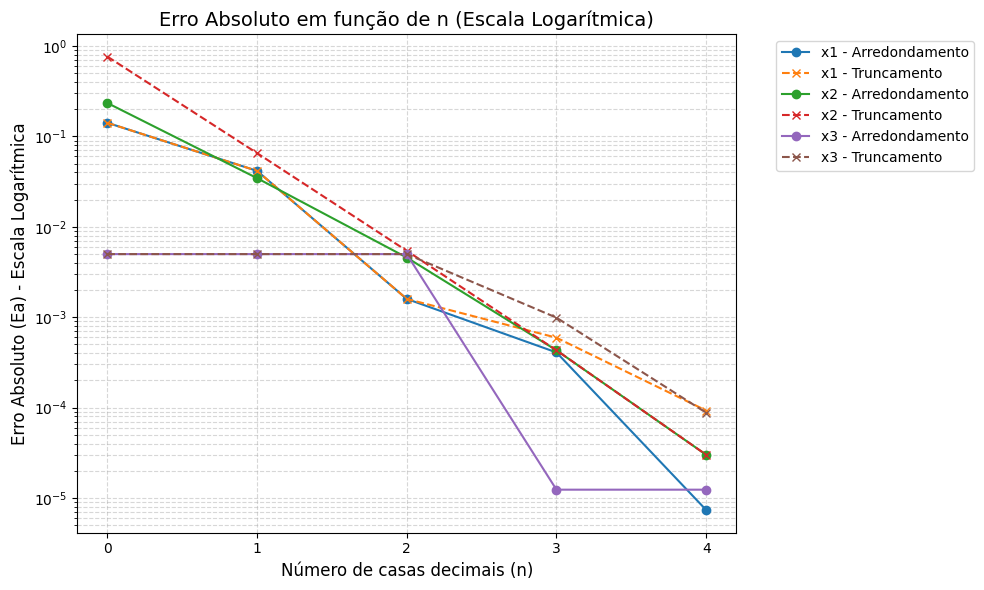

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt

x1 = 3.14159265
x2 = 98.76543
x3 = 0.00498765

valores = [(x1, "x1"), (x2, "x2"), (x3, "x3")]
casas_decimais = [0, 1, 2, 3, 4]

def xtrunc(x, n):
    return math.trunc(x * (10**n)) / (10**n)

def erro_absoluto(x_orig, x_aprox):
    return abs(x_orig - x_aprox)

def erro_rel(x_orig, x_aprox):
    return erro_absoluto(x_orig, x_aprox) / abs(x_orig)

def erro_per(x_orig, x_aprox):
    return 100 * erro_rel(x_orig, x_aprox)

dados_tabela = []

for x, nome in valores:
    for i in casas_decimais:
        r_aprox = round(x, i)
        r_ea = erro_absoluto(x, r_aprox)
        r_er = erro_rel(x, r_aprox)
        r_ep = erro_per(x, r_aprox)

        dados_tabela.append({
            'Variável': nome,
            'n': i,
            'Método': 'Arredondamento',
            'Aproximação': r_aprox,
            'Ea': r_ea,
            'Er': r_er,
            'E%': r_ep
        })

        t_aprox = xtrunc(x, i)
        t_ea = erro_absoluto(x, t_aprox)
        t_er = erro_rel(x, t_aprox)
        t_ep = erro_per(x, t_aprox)

        dados_tabela.append({
            'Variável': nome,
            'n': i,
            'Método': 'Truncamento',
            'Aproximação': t_aprox,
            'Ea': t_ea,
            'Er': t_er,
            'E%': t_ep
        })

df = pd.DataFrame(dados_tabela)

pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.6f' % x)

print("Item A da lista")
print(df.to_string(index=False))

plt.figure(figsize=(10, 6))

for nome in ['x1', 'x2', 'x3']:
    sub_df_arr = df[(df['Variável'] == nome) & (df['Método'] == 'Arredondamento')]
    sub_df_tru = df[(df['Variável'] == nome) & (df['Método'] == 'Truncamento')]

    plt.plot(sub_df_arr['n'], sub_df_arr['Ea'], marker='o', linestyle='-', label=f'{nome} - Arredondamento')

    plt.plot(sub_df_tru['n'], sub_df_tru['Ea'], marker='x', linestyle='--', label=f'{nome} - Truncamento')

plt.yscale('log')

plt.xlabel('Número de casas decimais (n)', fontsize=12)
plt.ylabel('Erro Absoluto (Ea) - Escala Logarítmica', fontsize=12)
plt.title('Erro Absoluto em função de n (Escala Logarítmica)', fontsize=14)
plt.xticks([0, 1, 2, 3, 4])
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("Arredondar sempre gera erro menor ou igual ao truncamento? Sim, pelos resultados obtidos o erro do arredondamento é sempre menor ou igual ao do truncamento")

Pressão_arterial =